# Exploratory analysis: catalog features and fingerprint sanity checks

Everything here is read from `db/licensing.db` after running the pipeline (see README).
Outputs in this notebook come from an actual execution (`jupyter nbconvert --execute`).

In [1]:
import sys, json
sys.path.insert(0, '..')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.db import connect, ROOT
from src.fingerprint import load_fingerprints, HASH_RATE_HZ
from src.detector import agreement_by_offset
pd.set_option('display.width', 120)
conn = connect()
df = pd.read_sql_query('SELECT * FROM tracks JOIN audio_features USING (track_id)', conn)
seed = pd.read_csv(ROOT / 'data' / 'catalog_seed.csv')
df = df.merge(seed[['track_id', 'declared_bpm']], on='track_id')
print(len(df), 'tracks,', round(df.duration_sec.sum() / 60, 1), 'minutes of audio')

47 tracks, 162.7 minutes of audio


## Catalog composition

In [2]:
print(df.license_type.value_counts().to_string(), '\n')
print('instrumental (rule-derived from uploader tags):', int(df.is_instrumental.sum()), 'of', len(df), '\n')
tags = df.mood_tags.fillna('').str.split(',').explode()
print(tags[tags != ''].value_counts().to_string())

license_type
cc-by-3.0    34
cc0           7
cc-by-2.5     6 

instrumental (rule-derived from uploader tags): 26 of 47 

mood_tags
chill           18
driving         13
acoustic        11
ambient         11
upbeat           9
cinematic        9
funky            7
jazzy            6
experimental     6
romantic         4
melancholic      2
dark             1


## Feature distributions

,tempo_bpm,energy_rms,spectral_centroid,zero_crossing_rate,duration_sec
count,47.000,47.000,47.000,47.000,47.000
mean,121.086,0.171,1959.289,0.090,207.654
std,24.760,0.082,891.122,0.054,58.409
min,78.303,0.048,275.059,0.018,88.974
25%,103.359,0.115,1392.126,0.055,161.594
50%,117.454,0.162,1854.728,0.076,208.065
75%,135.999,0.209,2527.370,0.111,239.174
max,184.570,0.398,4477.178,0.318,359.132


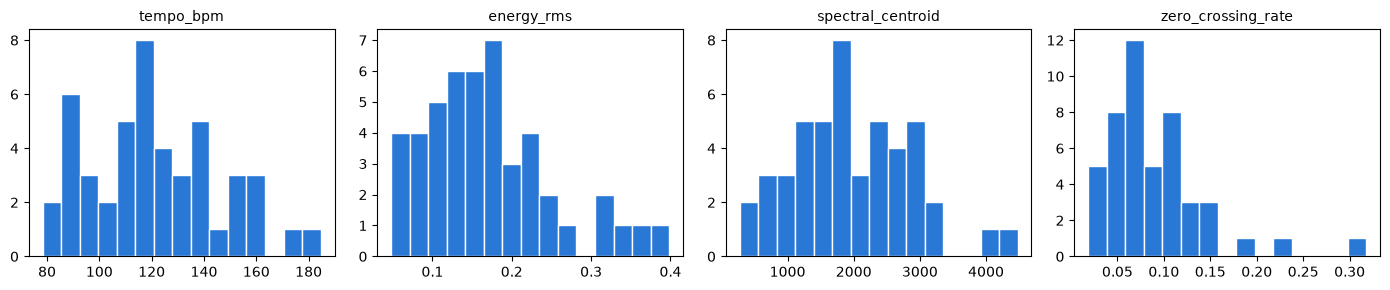

In [3]:
feats = ['tempo_bpm', 'energy_rms', 'spectral_centroid', 'zero_crossing_rate']
display(df[feats + ['duration_sec']].describe().round(3))
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, f in zip(axes, feats):
    ax.hist(df[f], bins=15, color='#2a78d6', edgecolor='white')
    ax.set_title(f, fontsize=10)
plt.tight_layout()

In [4]:
display(df[feats].corr().round(2))

,tempo_bpm,energy_rms,spectral_centroid,zero_crossing_rate
tempo_bpm,1.00,-0.16,-0.28,-0.27
energy_rms,-0.16,1.00,0.42,0.17
spectral_centroid,-0.28,0.42,1.00,0.91
zero_crossing_rate,-0.27,0.17,0.91,1.00


## How trustworthy is librosa's tempo?

43 uploaders typed a BPM into ccMixter. That's self-reported and sometimes rough, but it's an independent
reference. A reading counts as *matching* within 4%, and as an *octave error* if half or double the
librosa tempo is within 4%.

In [5]:
t = df.dropna(subset=['declared_bpm']).copy()
def classify(r):
    for mult, label in ((1, 'match'), (2, 'octave (librosa half)'), (0.5, 'octave (librosa double)')):
        if abs(r.tempo_bpm * mult - r.declared_bpm) / r.declared_bpm <= 0.04:
            return label
    return 'other'
t['agreement'] = t.apply(classify, axis=1)
print(t.agreement.value_counts().to_string())
display(t[t.agreement != 'match'][['track_id', 'title', 'tempo_bpm', 'declared_bpm', 'agreement']]
        .round(1).sort_values('agreement'))

agreement
match                      28
other                       7
octave (librosa double)     5
octave (librosa half)       2


,track_id,title,tempo_bpm,declared_bpm,agreement
2,ccm_14414,(PIANO) A minor improvisation on Sunday,161.5,82.0,octave (librosa double)
12,ccm_25202,Dollheads,117.5,59.0,octave (librosa double)
23,ccm_31670,Start Again,161.5,80.0,octave (librosa double)
29,ccm_33867,Quiet Rain,136.0,70.0,octave (librosa double)
32,ccm_35879,Two Guitars,161.5,80.0,octave (librosa double)
36,ccm_4209,A New System DNB,92.3,185.0,octave (librosa half)
38,ccm_43098,Drive,83.4,165.0,octave (librosa half)
0,ccm_11479,Paloseco Brazz Muted Trumpet Blues Samples,107.7,65.0,other
24,ccm_32423,Spinnin',103.4,153.7,other
30,ccm_34419,Reflections in the Rain,136.0,75.0,other


This is why the scorer considers half/double-time readings (`--no-octave` turns that off): octave
errors are common, and some "other" cases may be uploader typos or tracks with tempo changes.

## Fingerprint sanity checks

In [6]:
fps = load_fingerprints(conn)
lengths = pd.Series({k: len(v) for k, v in fps.items()})
rate = lengths / df.set_index('track_id').duration_sec
print(f'hashes per second: median {rate.median():.3f}, min {rate.min():.3f}, max {rate.max():.3f} '
      f'(Chromaprint nominal {HASH_RATE_HZ:.3f})')

hashes per second: median 7.973, min 7.834, max 8.017 (Chromaprint nominal 8.077)


In [7]:
# A slice of a reference must match itself exactly at its own offset.
ref = fps['ccm_30513']
s = agreement_by_offset(ref[400:481], ref)
print('self-match: argmax', int(s.argmax()), 'score', s.max())

self-match: argmax 400 score 1.0


### Music vs. unrelated music: close to 50%

If Chromaprint bits were uniformly random, two unrelated windows would agree on about 50% of bits. The
check below slides one 10 s window from each track across every *other* track.

In [8]:
rng = np.random.default_rng(0)
rows = []
ids = sorted(fps)
for a in ids:
    start = rng.integers(0, len(fps[a]) - 81)
    w = fps[a][start:start + 81]
    for b in ids:
        if a == b: continue
        sc = agreement_by_offset(w, fps[b])
        rows.append({'query': a, 'query_sec': start / HASH_RATE_HZ, 'ref': b, 'mean': sc.mean(),
                     'max': sc.max(), 'best_ref_sec': sc.argmax() / HASH_RATE_HZ})
cross = pd.DataFrame(rows)
print(cross[['mean', 'max']].describe().round(3))
display(cross.sort_values('max', ascending=False).head(3).round(3))

           mean       max
count  2162.000  2162.000
mean      0.503     0.570
std       0.022     0.026
min       0.413     0.481
25%       0.490     0.553
50%       0.504     0.569
75%       0.516     0.585
max       0.579     0.840


,query,query_sec,ref,mean,max,best_ref_sec
1363,ccm_33867,105.857,ccm_34419,0.512,0.840,99.048
1656,ccm_4209,23.895,ccm_11479,0.573,0.726,12.629
414,ccm_23691,125.543,ccm_11479,0.545,0.693,7.429


Unrelated music averages very close to 0.5, as expected. The one outlier pair (0.84) is not
unrelated: **"Reflections in the Rain" (ccm_34419) is a ccMixter remix of "Quiet Rain" (ccm_33867)**, and
both are in the catalog. ccMixter is a remix community, so shared stems are normal. A recording of one
can legitimately match the other. That matters for licensing (a remix can carry a licensed original), and
no test recording includes either track, so the detector's numbers don't depend on it.

### Noise vs. the catalog: the spread differs by reference

The detector doesn't only see music. Here are the windows of a crowd-and-talking recording with no
music at all (`test_neg_01`) against every reference.

In [9]:
from src.fingerprint import fingerprint_file
q = fingerprint_file(ROOT / 'data/audio/simulated_events/test_neg_01.mp3')
rows = []
for s in range(0, len(q) - 81, 81):
    for t in ids:
        sc = agreement_by_offset(q[s:s + 81], fps[t])
        rows.append({'window': s, 'ref': t, 'mean': sc.mean(), 'std': sc.std(), 'max': sc.max(),
                     'z_of_max': (sc.max() - sc.mean()) / sc.std()})
noise = pd.DataFrame(rows)
by_ref = noise.groupby('ref')[['mean', 'std', 'max', 'z_of_max']].mean().sort_values('std')
print('per-reference spread (std over offsets) ranges from', round(by_ref['std'].min(), 3),
      'to', round(by_ref['std'].max(), 3))
display(by_ref.round(3).iloc[[0, 1, 2, -3, -2, -1]])

per-reference spread (std over offsets) ranges from 0.017 to 0.092


,mean,std,max,z_of_max
ref,,,,
ccm_56668,0.454,0.017,0.501,2.799
ccm_30513,0.541,0.017,0.587,2.685
ccm_31670,0.476,0.018,0.532,3.014
ccm_23691,0.503,0.052,0.620,2.263
ccm_38009,0.492,0.056,0.637,2.592
ccm_58268,0.512,0.092,0.735,2.430


Against pure noise, references with long quiet or textural passages (e.g. ccm_58268, "After the storm",
which contains storm ambience) produce very wide score distributions. Their best offset reaches bit
agreement in the 0.7s, about what a real match gets at 0 dB SNR. A fixed bit-agreement threshold
would either flag them in silence or miss real matches. Dividing by each reference's own spread
(`peak_z`) evens this out. The detector also needs two non-overlapping windows to agree on alignment.
See `src/detector.py` and the README.

### Repetition inside a track

Loop-based tracks match *themselves* at other offsets, so the exact position within a track can be
ambiguous even when the identity isn't.

In [10]:
for t in ['ccm_30513', 'ccm_43098', 'ccm_2905']:
    r = fps[t]; s = 400
    sc = agreement_by_offset(r[s:s + 81], r)
    others = np.delete(sc, range(s - 8, s + 9))
    print(f'{t}: true offset 1.000, best OTHER offset {others.max():.3f}, mean {others.mean():.3f}')

ccm_30513: true offset 1.000, best OTHER offset 0.912, mean 0.645
ccm_43098: true offset 1.000, best OTHER offset 0.828, mean 0.604
ccm_2905: true offset 1.000, best OTHER offset 0.642, mean 0.534
